# Practical 2: Autoregressive modeling for Lagrangian Systems

This hands-on practical covers the following subjects:
- Graph-based dataset processing and training of neural surrogates
- Autoregressive time-stepping models
- Lagrangian data: particle-based datasets with simple interactions that produce complex behaviour
- Graph neural networks
- Symmetry in particle-based systems
- Equivariant graph neural networks
- Evaluating neural surrogates of Lagrangian systems

The learning goals of this practical can be summarized as follows:
- You understand how autoregressive models can be used to predict the time evaluation of particle-based systems
- You know how graph neural networks represent particle-based systems as graphs and why they are well-suited to Lagrangian data
- You grasp the role of symmetry in these systems and how equivariant GNNs incorporate this to improve generalization and physical consistency
- You are able to qualitatively and quantitatively evaluate data-driven models for Lagrangian systems, recognize failure modes and analyze computational resources

![SegmentLocal](figures/boids_3d.gif)
![SegmentLocal](figures/nbody_charged.gif)
![SegmentLocal](figures/nbody_gravity.gif)



In [ ]:
import torch as T
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch_geometric.data import Data, DataLoader as GraphDataLoader
from torch_geometric.utils import to_dense_batch
from torch_geometric.nn import radius_graph
import lightning as L
from lightning.pytorch.profilers import SimpleProfiler
import os
import pickle
import numpy as np 
import matplotlib.pyplot as plt
from IPython.display import HTML

print(f"Success! Running PyTorch {T.__version__} and Lightning {L.__version__}")
cuda_available = T.cuda.is_available()
if cuda_available:
    print(f"CUDA is available! Device count: {T.cuda.device_count()}")
else:
    print("CUDA is not available.")

L.seed_everything(42, workers=True)


**<h3 style="color:orange">Please make sure any LLM coding assistant like Github Copilot or Cursus is turned OFF! Also in Google Colab!</h2>**

**<h4 style="color:orange">We want you to learn and think critically, not to let LLMs do your work for you.</h4>**

**<h4 style="color:orange">Ask your group members or the internet for help, BEFORE asking your favorite chatbot.</h4>**

<img src="figures/copilot.png">
<img src="figures/colab.png" style="width:500px">

## Before we begin: PyTorch Lightning

In this practical we will use the deep learning framework called PyTorch Lightning (https://lightning.ai/docs/pytorch/stable/home/introduction). 

It is made for professional AI researchers and machine learning engineers and offers a more flexible and scalable approach for organizing and implementing code than regular PyTorch. 

Please watch this short video that explains the concept of Lightning. Afterwards, please read the "Lightning in 15 minutes" guide using the link above

<video width=80% controls>
<source src="figures/lightning.mp4" type="video/mp4">
</video>

## Dataset: Charged Particles

We start off by looking at a system of simulated charged particles under the influence of Coulomb's law.
Coulomb's law describes the amount of force between two electrically charged particles at rest, called the electrostatic force.

The electrostatic force $F$ between particles $i$ and $j$ with charge $q_i \in \{\pm q\}$ and positions $x_i$ and $x_j$ is defined as:
$$ F_{ij} = C \cdot sign(q_i \cdot q_j) \frac{x_i-x_j}{||x_i-x_j||^3}$$

Our first dataset consists of 1000 simulations of 10 particles over $T=199$ timesteps, each having a positive or negative charge, which changes across simulations.
We subsample the trajectories by only using every 5th frame to reduce computational load, so we are left with $T=40$ frames in each trajectory.

For more details, we used the setup introduced in this paper: https://arxiv.org/pdf/1802.04687

![SegmentLocal](figures/nbody_charged.gif)

### Data Processing
Below the data loading, saving, splitting and batching logic is implemented using a PyTorch Dataset class and a LightningDatamodule

The *ParticleDatasetBase* loads and holds the actual particle simulation data.
We need a way to both get individual timesteps and whole trajectories as data sample (step-by-step training vs. rollout inference), so *ParticleTrajectoryDataset* and *ParticleStepDataset* are instantiations of the base class and define how one data sample, either a whole particle trajectory or one timestep, can be retrieved. 

The *DataModule* class implements the train/val/test splitting and defines the Pytorch Dataloaders, which form mini-batches from our dataset.

See https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html and https://lightning.ai/docs/pytorch/stable/data/datamodule.html#lightningdatamodule for in-depth descriptions if you are not familiar with the PyTorch Dataset or Dataloader classes.

In [ ]:
class ParticleDatasetBase(Dataset):
    """Loads particle simulation data. Subclasses define how items are indexed."""

    def __init__(self, path):
        self.path = path
        self.nodes = T.tensor([], dtype=T.float32)  # (n_sim, traj_len, ...)
        self.charges = T.tensor([], dtype=T.int32)  # (n_particles,)
        self.n_simulations = 0
        self.traj_length = 0

    def load_data(self):
        if not os.path.exists(self.path):
            raise FileNotFoundError(
                f"Data file not found at {self.path}. Please check the path and try again."
            )
        with open(self.path, "rb") as f:
            data = pickle.load(f)

        positions = T.tensor(data["nodes"], dtype=T.float32)[:, ::5]  # (n_sim, traj_len, 10, 3)
        # Take the difference between consecutive positions to get velocities. This will result in one less timestep frame
        velocities = T.diff(positions, dim=1)  # (n_sim, traj_len - 1, 10, 3)
        self.nodes = T.cat(  # Concatenate positions and velocities along the feature dimension
            [positions[:, 1:], velocities], dim=-1
        )  # (n_sim, traj_len - 1, 10, 6)
        self.charges = T.tensor(data["charges"], dtype=T.int32)  # (n_particles,)
        self.n_simulations = self.nodes.shape[0]
        self.traj_length = self.nodes.shape[1] - 1

        print(
            f"\nLoaded data from {self.path} containing {len(self)} samples of shape {self.nodes[0].shape}.\n"
        )

class ParticleTrajectoryDataset(ParticleDatasetBase):
    """One sample = one full trajectory: nodes has shape (traj_len, ...)."""

    def __len__(self):
        return self.n_simulations

    def __getitem__(self, idx):
        return {"X": self.nodes[idx], "charges": self.charges}


class ParticleStepDataset(ParticleDatasetBase):
    """One sample = one timestep: nodes has shape (...)."""

    def __len__(self):
        return self.n_simulations * self.traj_length

    def __getitem__(self, idx):
        sim_idx, t_idx = idx // self.traj_length, idx % self.traj_length
        return {
            "X": self.nodes[sim_idx, t_idx],
            "X_next": self.nodes[sim_idx, t_idx + 1],
            "charges": self.charges,
        }

class DataModule(L.LightningDataModule):
    """Lightning DataModule class that manages the dataset splitting and the dataloaders"""

    def __init__(self, dataset, batch_size, train_split, val_split, seed=42):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.train_split = train_split
        self.val_split = val_split
        self.seed = seed

    def prepare_data(self):
        self.dataset.load_data()

    def setup(self, stage=None):
            if getattr(self, "train_set", None) is not None:
                return

            train_size = int(len(self.dataset) * self.train_split)
            val_size = int(len(self.dataset) * self.val_split)

            self.train_set = Subset(self.dataset, list(range(len(self.dataset)))[:train_size])
            self.val_set = Subset(
                self.dataset, list(range(len(self.dataset)))[train_size : train_size + val_size]
            )
            self.test_set = Subset(
                self.dataset, list(range(len(self.dataset)))[train_size + val_size :]
            )

    def train_dataloader(self):
        return DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_set, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_set, batch_size=self.batch_size)

    def predict_dataloader(self):
        return DataLoader(self.test_set, batch_size=self.batch_size)

path = os.path.join("data", "nbody", "charged_dataset.pkl")
charged_dataset = ParticleTrajectoryDataset(path=path)
charged_dataset.load_data()

### Data Exploration
Before we train any models, let's first get a sense of the data structure, how the state evolves and look at some statistics to get familiar with the data.

We analyze the following quantities about the system:
- Positions $X \in \mathbb{R}^{N \times T \times 10 \times 3}$
- Velocity magnitudes $||\dot X||_2 \in \mathbb{R}^{N \times T \times 10}$ 
- Accelerations $\ddot X \in \mathbb{R}^{N \times T \times 10 \times 3}$ 
- Distance travelled $\sum^T_{t=1} ||\dot X||_2 \in \mathbb{R}^{N \times 10}$
- Mean Velocity Magnitude over Time $\overline{||\dot X||}_2 \in \mathbb{R}^{T}$ 
- Mean Acceleration Magnitude over Time $\overline{||\ddot X||}_2 \in \mathbb{R}^{T}$ 
- Mean Distance between Particles over Time $\overline{||x^t_i - x^t_j||} \in \mathbb{R}^{T}$

Where $N$ is the number of samples, $T$ is the number of timesteps, 10 is the number of particles and 3 the number of spatial dimensions

**Optional Exercise:** Think of other possible interesting properties of charged particles moving around and plot them

In [ ]:
dt = 1  # Time step size

# Positions shape: (#samples, #time_steps, #particles, 3)
positions = np.stack([sample['X'][:, :, :3].numpy() for sample in charged_dataset], axis=0)
def calculate_kinematics(positions, dt):
    velocities = np.gradient(positions, dt, axis=1)  # Velocities as differences in positions
    accelerations = np.gradient(velocities, dt, axis=1)  # Accelerations as differences in velocities
    vel_magnitudes = np.linalg.norm(velocities, axis=-1)  # Magnitudes of velocities
    acc_magnitudes = np.linalg.norm(accelerations, axis=-1)  # Magnitudes of accelerations
    relative_positions = positions[:, :, None] - positions[:, :, :, None]   # Displacement vectors between particles
    distances = np.linalg.norm(relative_positions, axis=-1)  # Distances between particles
    distances = distances.reshape(*distances.shape[:2], -1)
    arc_lengths = np.sum(vel_magnitudes, axis=1)  # Arc lengths as the sum of velocity magnitudes over time
    mean_vel_over_time = np.mean(vel_magnitudes, axis=(0, 2))  # Average velocity magnitude over time
    mean_acc_over_time = np.mean(acc_magnitudes, axis=(0, 2))  # Average acceleration magnitude over time
    mean_dist_over_time = np.mean(distances, axis=(0, 2))  # Average distance over time

    return {
        "velocities": velocities,
        "accelerations": accelerations,
        "vel_magnitudes": vel_magnitudes,
        "acc_magnitudes": acc_magnitudes,
        "distances": distances,
        "arc_lengths": arc_lengths,
        "mean_vel_over_time": mean_vel_over_time,
        "mean_acc_over_time": mean_acc_over_time,
        "mean_dist_over_time": mean_dist_over_time
    }

def plot_kinematics_summary(hist_quantities, hist_names, hist_colors,
                            line_quantities, line_names, line_colors, displ_error_labels= None, model_labels=None):
    """2x4 grid: row 0 = histograms, row 1 = temporal mean +/- std."""
    fig, axs = plt.subplots(2, 4, figsize=(12.5, 5.5), dpi=300)

    def _as_tuple(x):
        return x if isinstance(x, tuple) else (x,)

    def _apply_ax_styles(ax):
        """Applies axis frame and tick styling locally."""
        ax.tick_params(axis='both', labelsize=7)
        for spine in ax.spines.values():
            spine.set_color('#333333')
            spine.set_linewidth(1.5)

    # --- Row 0: Histograms ---
    for ax, vals, name, color in zip(axs[0], hist_quantities, hist_names, hist_colors):
        _apply_ax_styles(ax)
        vals_t, color_t = _as_tuple(vals), _as_tuple(color)
        labels_t = model_labels if (model_labels and len(vals_t) > 1) else [None] * len(vals_t)

        flat = [v.flatten() for v in vals_t]
        lo = min(np.quantile(v, 0.01) for v in flat)
        hi = max(np.quantile(v, 0.99) for v in flat)
        bins = np.linspace(lo, hi, 60)

        for v, c, lbl in zip(flat, color_t, labels_t):
            alpha = 0.4 if len(vals_t) > 1 else 0.9
            ax.hist(v, bins=bins, color=c, alpha=alpha, edgecolor='white',
                    linewidth=0.3, zorder=2)
            label = f'μ = {np.mean(v):.2f}' if lbl is None else f'{lbl} μ = {np.mean(v):.2f}'
            ax.axvline(np.mean(v), color=c, linestyle='--', linewidth=0.8,
                       zorder=3, label=label)

        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_xlabel(name, fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(loc='best', fontsize=7, frameon=False)
        ax.grid(alpha=0.5, linestyle='--', linewidth=0.5, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)

    # --- Row 1: Temporal statistics ---
    for ax, vals, name, color in zip(axs[1], line_quantities, line_names, line_colors):
        _apply_ax_styles(ax)
        vals_t, color_t = _as_tuple(vals), _as_tuple(color)
        labels_t = model_labels if (model_labels and len(vals_t) > 1) else [None] * len(vals_t)
        if displ_error_labels is not None and name == 'Displ. Error':
            labels_t = displ_error_labels

        for v, c, lbl in zip(vals_t, color_t, labels_t):
            t = np.arange(len(v))
            std = np.std(v)
            ax.plot(t, v, color=c, linewidth=2.5, zorder=2, label=lbl, alpha=0.9)
            ax.fill_between(t, v - std, v + std, color=c, alpha=0.2, linewidth=0)

        ax.set_title(f'{name} over Time', fontsize=11, fontweight='bold')
        ax.set_xlabel('Timestep', fontsize=9)
        ax.set_ylabel(name, fontsize=9)
        if any(labels_t):
            ax.legend(loc='best', fontsize=7, frameon=False)
        ax.grid(alpha=0.5, linestyle='--', linewidth=0.5, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide unused axes if fewer than 4 plots are given
    for ax in axs[1][len(line_quantities):]:
        ax.axis('off')
    for ax in axs[0][len(hist_quantities):]:
        ax.axis('off')

    fig.tight_layout(pad=0.5, h_pad=1.0)
    return fig, axs

properties = calculate_kinematics(positions, dt)

hist_names = ['Positions', 'Velocity magnitude', 'Acceleration magnitude', 'Distance travelled']
hist_values = [positions, properties['vel_magnitudes'], properties['acc_magnitudes'], properties['arc_lengths']]
hist_colors = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']

line_names = ['Avg Velocity', 'Avg Acc.', 'Avg Distance']
line_values = [properties['mean_vel_over_time'], properties['mean_acc_over_time'], properties['mean_dist_over_time']]
line_colors = ['#DD8452', '#C44E52', '#8172B2']

%matplotlib inline
fig, axs = plot_kinematics_summary(hist_values, hist_names, hist_colors,
                                    line_values, line_names, line_colors)
plt.show()

Interesting. 

The position histogram shows that the system has no directional bias. 
Velocity magnitude distribution is skewed instead of symmetric.
The acceleration magnitude distribution is even more skewed. The data contains rare, high-acceleration transient (short-lived) events (probably from particles getting very close).

Looking at the temporal statistics, we see that the stystem is not stationary. 
Mean velocity rises sharply and then plateaus. Mean acceleration spikes and then slowly decays. And lastly, the system slowly expands, as the average distance between particles grows over time. 


## Autoregressive Model

Now let's get started with building a neural surrogate, in the form of an autoregressive model. 

As seen in the last practical, an autoregressive model predicts the next state of a system from its current (and possibly past) states, one step at a time: given $x_t$, learn $f_\theta$ such that $\hat{x}_{t+1}=f_\theta(x_t)$. To generate a trajectory, we apply the model repeatedly, feeding each prediction back in as the next input, $\hat{x}_{t+2} = f_\theta(\hat{x}_{t+1})$ and so on. This is exactly the setting we care about here, given the current positions and velocities of our charged particles, we want to learn a function that predicts their state one timestep ahead, and then roll this forward to produce full simulated trajectories.

### Architecture: Simple MLP

One of the simplest possible choices for $f_\theta$ is a Multi-Layer Perceptron (MLP): a stack of fully-connected layers with nonlinearities in between, applied directly to a flattened representation of the current state. It has no notion of particles, edges or interactions, it simply treats the whole system as one big vector and learns a mapping from "all positions and velocities now" to "all velocities next". This tells us how well a model without any structural assumptions about the physics can do. 



In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers=3):
        super(SimpleMLP, self).__init__()
        self.n_layers = n_layers
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.SiLU(),
            *[nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.SiLU()) for _ in range(n_layers - 1)],
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        mlp_input = x.flatten(start_dim=1)  # Flatten the input except for the batch dimension
        mlp_output = self.mlp(mlp_input) 
        output = mlp_output.view(x.shape[0], x.shape[1], -1)  # Reshape the output to match the input shape
        return output

simple_mlp = SimpleMLP(input_dim=6*10, hidden_dim=64, output_dim=3*10, n_layers=3)
test_input = T.randn(16, 10, 6)  # Test with a minibatch of 16
test_output = simple_mlp(test_input)  


## **Exercise 1** 
### There appears to be a bug in the code, please fix it so that we can check how an MLP will perform here.

### Training and Inference loop

Here we implement the training (*training_step*), validation (*validation_step*) and prediction (*predict_step*) logic using a LightningModule. Autoregressive rollout is implemented in the *predict_step* method by storing intermediate positions or velocity predictions in the rollout tensor. Read through the implementation and think about what each part does.

See https://lightning.ai/docs/pytorch/stable/common/lightning_module.html for more details.

In [ ]:
class ParticleModel(L.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        inputs = batch["X"]
        targets = batch["X_next"][..., 3:]
        outputs = self(inputs)  # Shape: (batch_size, num_particles, 3)
        loss = F.mse_loss(outputs, targets)  # Mean Squared Error loss
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._step(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._step(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        rollout = T.zeros_like(batch["X"])  # Initialize a tensor to hold all inputs/outputs
        rollout[:, 0] = batch["X"][:, 0]  # Get t=1 of trajectory for first prediction input
        for t in range(0, rollout.shape[1] - 1):
            old_positions = rollout[:, t, :, :3]

            model_input = rollout[:, t]  # Use model's own prediction for next input

            new_velocities = self(model_input)
            new_positions = old_positions + new_velocities

            rollout[:, t + 1] = T.cat([new_positions, new_velocities], dim=-1)

        return rollout

    def configure_optimizers(self):
        return T.optim.Adam(self.parameters(), lr=self.learning_rate)

class LossHistory(L.Callback):
    def __init__(self):
        self.train_loss, self.val_loss = [], []
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get("train_loss").item())
    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(trainer.callback_metrics.get("val_loss").item())

Now we can start to train our little autoregressive MLP model using the Lightning Trainer class with `trainer.fit()` after the dataset, datamodule, model and trainer have been setup.

The following hyperparameters could be adjusted and will have impact on the performance: *batch_size, train_split* and *val_split, hidden_dim, n_layers, learning_rate, predict_velocity* and *max_epochs*.

Inference is performed using `trainer.predict()`, which loads the full trajectories and uses the `predict_step` method to perform the autoregressive rollout, starting from $x_{t=1}$.

In [ ]:
# These parameters will be used for all the different models for a fair comparison
MAX_EPOCHS = 40
BATCH_SIZE = 32
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
LIMIT_TRAIN_BATCHES = 300
LIMIT_VAL_BATCHES = 30
LEARNING_RATE = 5e-4

In [ ]:
charged_step_dataset = ParticleStepDataset(path)
module = DataModule(charged_step_dataset, batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

simple_mlp = SimpleMLP(input_dim=6*10, hidden_dim=128, output_dim=3*10, n_layers=4)  # Input dim is 6 * 10 (3 for position + 3 for velocity, for each particle)
model = ParticleModel(model=simple_mlp, learning_rate=LEARNING_RATE)

loss_history = LossHistory()
profiler = SimpleProfiler(dirpath="profiler_logs", filename="mlp")
trainer = L.Trainer(max_epochs=MAX_EPOCHS, accelerator="auto", profiler=profiler, callbacks=[loss_history], limit_train_batches=LIMIT_TRAIN_BATCHES, limit_val_batches=LIMIT_VAL_BATCHES, logger=False, enable_checkpointing=False)

trainer.fit(model, datamodule=module)

charged_trajectory_dataset = ParticleTrajectoryDataset(path)
traj_module = DataModule(charged_trajectory_dataset, batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

rollouts = trainer.predict(model, datamodule=traj_module)

predicted_positions_mlp = T.cat(rollouts, dim=0).numpy()[..., :3]
ground_truth_positions_mlp = T.cat([batch["X"] for batch in traj_module.predict_dataloader()], dim=0).numpy()[..., :3]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

ax.plot(loss_history.train_loss, label='Train Loss', color='tab:blue')
ax.plot(loss_history.val_loss, label='Validation Loss', color='tab:orange')
# ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.title('Training and Validation Loss')
%matplotlib inline
plt.show()

### Evaluation & Reflection

Great, now let's see if our MLP is able to generate accurate trajectories and whether it has learned any meaningful patterns from the data.

As pointwise error metrics that define accuracy, we use two measures called Average Displacement Error (ADE) and Final Displacement Error (FDE), often used in the trajectory forecasting literature. They are defined as: 

$ ADE(X,\hat{X}) = \overline{|| X^t_i - \hat{X}^t_i ||_2} , \ \ \ FDE(X^{t=T}, \hat{X}^{t=T})= \overline{|| X^{t=T}_i - \hat{X}^{t=T}_i ||_2} $, where $X \in \mathbb{R}^{40 \times 10 \times 3}$ in our case.

In addition, we look at the displacement errors over time to see how stable the rollout of our model is.

When doing Machine Learning for Science, we are often more interested in knowing how well a model is able to reproduce certain characteristics of the system we are modelling, besides looking at accuracy. Some fundamental system properties that are often looked at are:
 - **Conservation laws / invariants**: If the true system conserves energy, momentum, mass, or some other quantity (Noether's theorem), the surrogate should too
 - **Stability and boundedness**: Does the learned dynamical system stay in a bounded region, or does it blow up? This is related to dynamical systems theory and chaos plays a large role here.
 - **Long-term or asymptotic behaviour**: For chaotic or dissipative systems, exact trajectory matching is impossible. What er actually want is that the surrogate reproduces the statistics of the attractor
 - **Symmetries**: If the physical system is equivariant under a symmetry group, our surrogate ideally respects that structure exactly rather than approximately learning it from data (to be continued)
 - **Spectral or multiscale fidelity**: Does the surrogate get the right energy spectrum across scales (space or time), or does it smooth out higher-frequency content?

With this in mind, we can use some of the exploratory data analysis code to evaluate our model and quantify performance in terms of learned system behaviour.
 

In [ ]:
pred = calculate_kinematics(predicted_positions_mlp, dt)
gt = calculate_kinematics(ground_truth_positions_mlp, dt)

displacement_errors = np.linalg.norm(predicted_positions_mlp - ground_truth_positions_mlp, axis=-1)  # Shape: (n_samples, n_timesteps, n_particles)

ADE = np.mean(np.linalg.norm(predicted_positions_mlp - ground_truth_positions_mlp, axis=-1))
FDE = np.mean(np.linalg.norm(predicted_positions_mlp[:, -1] - ground_truth_positions_mlp[:, -1], axis=-1))
DE_over_time_mlp = np.mean(displacement_errors, axis=(0, 2))  # Mean over particles, shape: (n_timesteps)

print(f"Average Displacement Error (ADE): {ADE:.4f}")
print(f"Final Displacement Error (FDE): {FDE:.4f}")


hist_names = ['Positions', 'Velocity magnitude', 'Acceleration magnitude', 'Distance travelled']
hist_values = [(predicted_positions_mlp, ground_truth_positions_mlp),
               (pred['vel_magnitudes'], gt['vel_magnitudes']),
               (pred['acc_magnitudes'], gt['acc_magnitudes']),
               (pred['arc_lengths'], gt['arc_lengths'])]
cmap = plt.get_cmap('Paired')

# Extracting color pairs as RGBA tuples from the colormap
hist_colors_compare = [(cmap(0), cmap(1)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]
line_colors_compare = [(cmap(8), cmap(9)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]
line_names = ['Displ. Error', 'Avg Velocity', 'Avg Acc.', 'Avg Distance']
line_values = [DE_over_time_mlp,
               (pred['mean_vel_over_time'], gt['mean_vel_over_time']),
               (pred['mean_acc_over_time'], gt['mean_acc_over_time']),
               (pred['mean_dist_over_time'], gt['mean_dist_over_time'])]

%matplotlib inline
fig, axs = plot_kinematics_summary(hist_values, hist_names, hist_colors_compare,
                                    line_values, line_names, line_colors_compare, model_labels=['Pred.', 'GT.'])

### Interpretation

Overall, the MLP performs reasonably well given that it is a very simple baseline with **no explicit assumptions about the symmetries or physical structure of the system**. The model receives the complete particle state as a flattened vector and has to learn the dynamics directly from the data, without being told that particles interact pairwise or that the system should be invariant/equivariant to transformations such as particle permutations or spatial symmetries.

The aggregate statistics show that the MLP captures several important characteristics of the system. The predicted and ground-truth distributions have similar shapes, especially for the position and velocity distributions. The travelled-distance distribution is also reasonably close, although the model underestimates it somewhat.

However, the pointwise trajectory errors reveal an important limitation. The model obtains an ADE of around 2 and an FDE of around 5, with the displacement error increasing substantially over time. This is expected for an autoregressive model: small errors in one prediction are fed back into the model as inputs for the next prediction, so errors can accumulate over the rollout. The divergence between the predicted and ground-truth average velocity and distance towards the end of the trajectory is another indication of this error accumulation.

The code below can be used to plot both the predicted and ground truth trajectories for a more visual confirmation of the performance.

In [ ]:
import time


def make_gif_dots(
    trajectory: np.ndarray,
    filepath: str,
    box_size: float | None = None,
    fps: int = 15,
    dot_size: int = 120,
    elev: float = 20.0,
    azim: float = -60.0,
    rotate: bool = False,
    cmap_name: str = "viridis",
    tracer_width: float = 1.5,
    hold_seconds: float = 2.0
) -> None:
    from matplotlib import animation
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d.art3d import Line3DCollection
    import os

    T, N, _ = trajectory.shape
    colors = plt.get_cmap(cmap_name)(np.linspace(0, 1, N))

    if box_size is not None:
        xlim = ylim = zlim = (-box_size / 2, box_size / 2)
    else:
        pad = 0.05
        mins = trajectory.min(axis=(0, 1))
        maxs = trajectory.max(axis=(0, 1))
        span = maxs - mins
        span[span == 0] = 1.0
        mins, maxs = mins - pad * span, maxs + pad * span
        xlim, ylim, zlim = zip(mins, maxs)

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)  # type: ignore
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])  # type: ignore

    all_segments = np.stack([trajectory[:-1], trajectory[1:]], axis=2)  # (T-1, N, 2, 3)
    full_widths = np.linspace(0.3, tracer_width, T - 1) if T > 1 else np.array([])

    scat = ax.scatter(*trajectory[0].T, s=dot_size, c=colors, depthshade=False,  # type: ignore
                        edgecolors="black", linewidths=1.2)
    tracers = [ax.add_collection3d(Line3DCollection([], colors=colors[i], alpha=0.6), autolim=False) for i in range(N)]
    hold_frames = int(hold_seconds * fps)
    total_frames = T + hold_frames

    def draw_frame(frame):
        frame = min(frame, T - 1)  # Hold the last frame for the specified duration
        if rotate:
            ax.view_init(elev=elev, azim=azim + frame * 0.5)

        scat._offsets3d = trajectory[frame].T  # type: ignore
        if frame > 0:
            for i, lc in enumerate(tracers):
                lc.set_segments(all_segments[:frame, i])
                lc.set_linewidths(full_widths[:frame])

        return [scat, *tracers]

    anim = animation.FuncAnimation(fig, draw_frame, frames=total_frames, interval=1000 / fps, blit=False)
    os.makedirs(os.path.dirname(filepath) or ".", exist_ok=True)
    anim.save(filepath, writer="pillow", fps=fps)
    print(f"Saved GIF to {filepath}")
    plt.close(fig)

def show_gifs_with_labels(filepaths, labels, width=450):
    v = int(time.time())  # Unique identifier to prevent caching issues
    items = "".join(
        f'<div style="text-align:center; margin-right:10px;">'
        f'<img src="{fp}?v={v}" style="width:{width}px;"><br>{label}</div>'
        for fp, label in zip(filepaths, labels)
    )
    return HTML(f'<div style="display:flex; flex-wrap:wrap;">{items}</div>')

mins = np.min(np.concatenate([predicted_positions_mlp[0], ground_truth_positions_mlp[0]]), axis=(0, 1))
maxs = np.max(np.concatenate([predicted_positions_mlp[0], ground_truth_positions_mlp[0]]), axis=(0, 1))
span = maxs - mins
box_size = np.max(span) * 1.1
make_gif_dots(trajectory=predicted_positions_mlp[0], filepath="figures/predicted_trajectory.gif", box_size=box_size, fps=10, dot_size=240, elev=20.0, azim=-60.0, rotate=False, cmap_name="magma", tracer_width=4)
make_gif_dots(trajectory=ground_truth_positions_mlp[0], filepath="figures/ground_truth_trajectory.gif", box_size=box_size, fps=10, dot_size=240, elev=20.0, azim=-60.0, rotate=False, cmap_name="magma", tracer_width=4)

show_gifs_with_labels(["figures/predicted_trajectory.gif", "figures/ground_truth_trajectory.gif"], ["Predicted Trajectory", "Ground Truth Trajectory"])

## **Question 1** 
#### What information that is actually part of the dataset is currently not being used? Do you think this affects performance?

### Architecture: Graph Neural Network (GNN)
We now shift our focus towards a new type of architecture, Graph Neural Networks (GNNs). A Multi-Layer Perceptron treats the whole system as one flat vector, so its very difficult to know which particles are near each other for example. Graph Neural Networks fix this by representing the system as a graph: each particle becomes a node, and a modelled connection between two particles becomes an edge. As shown in the figure, this graph structure is stored as three pieces: an adjacency matrix A (panel b) that says which nodes are connected, node data X (panel c) holding each particle's own features (position, velocity, charge, ...), and edge data E (panel d) holding features that describe each connection (like the distance or relative velocity between two particles). This is a much more natural fit for physical Lagrangian systems, where the underlying dynamics really do come from pairwise interactions rather than some fixed global structure.

The key computational idea in a GNN is message passing: each node collects information from its neighbours, combines it, and updates its own representation. Stacking several rounds of message passing lets information propagate further across the graph, so a particle can "feel" the influence of others several hops away, not just its immediate neighbours. Because the same update rule is applied at every node regardless of how many neighbours it has or in what order they're listed, the model automatically generalizes to graphs of different sizes and is naturally invariant to how you order the particles, something an MLP cannot do without seeing every permutation during training.

For our charged particle system, this graph view is a natural match: nodes carry the position/velocity state of each particle, and edges can carry the pairwise information that actually drives the physics, giving the network the inductive bias it needs to learn the interaction rules rather than memorizing a fixed-size flattened state.

Below is a visualization of the data structures that represent a graph and it's features.

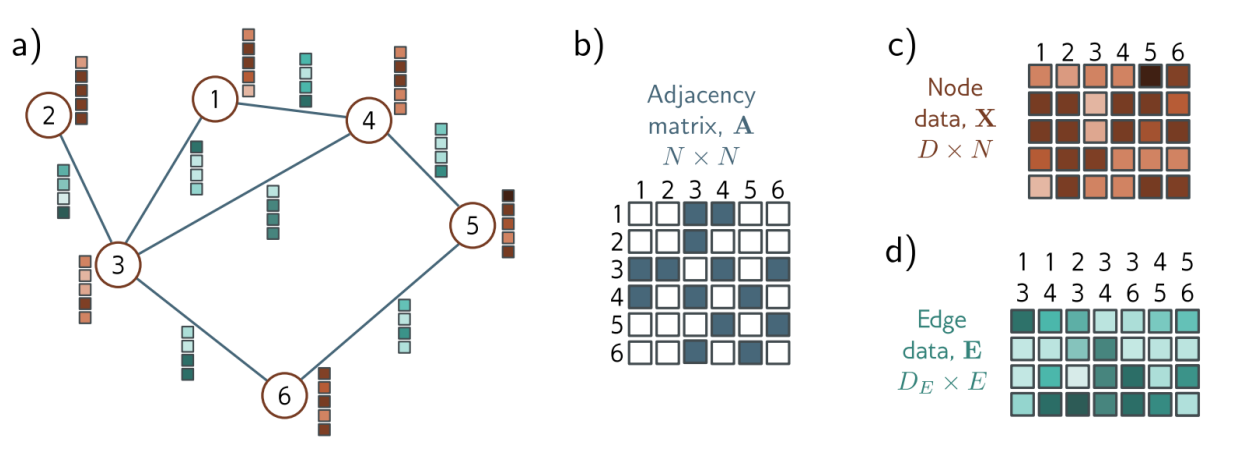

In [ ]:
class NeuralMessagePassingLayer(nn.Module):
    def __init__(self, in_features, in_edge_features, hidden_dim, out_features):
        super().__init__()
        self.message_mlp = nn.Sequential(
            nn.Linear(2* in_features + in_edge_features, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(in_features + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, out_features),
        )

    def forward(self, x, edge_index, edge_attr=None):
        """
        x:          (B*N, in_features)
        edge_index: (2, B*E) where E is the number of edges
        edge_attr:  (B*E, in_features) edge attributes
        """

        N = x.size(0)
        source_nodes, target_nodes = (
            edge_index  # Get source and target node indices for each edge
        )

        # Compute messages for each edge using the message MLP
        if edge_attr is not None:
            messages = self.message_mlp(T.cat([x[source_nodes], x[target_nodes], edge_attr], dim=-1))
        else:
            messages = self.message_mlp(T.cat([x[source_nodes], x[target_nodes]], dim=-1))

        # Aggregate messages using index_reduce_ to sum messages for each target node and average them
        # What index_reduce_ is doing, conceptually:
        # for each edge e with target node t = target_nodes[e]:
        #     aggregated_messages[t] += messages[e]
        # aggregated_messages /= counts_of_messages_per_node
        #
        # this is called a "scatter-mean": group messages by destination node, then sum and average them. Its much faster than a for loop
        aggregated_messages = T.zeros(N, messages.size(-1), device=x.device)
        aggregated_messages.index_reduce_(0, target_nodes, messages, reduce="mean")

        # Update node features
        x = self.node_mlp(x)
        x = T.cat([x, aggregated_messages], dim=-1)

        return x


class GNN(nn.Module):
    """"""

    def __init__(self, input_dim, hidden_dim, output_dim, in_edge_features=0):
        super().__init__()
        self.projection = nn.Linear(input_dim, hidden_dim)

        self.message_passing1 = NeuralMessagePassingLayer(
            hidden_dim, in_edge_features, hidden_dim, hidden_dim
        )
        self.message_passing2 = NeuralMessagePassingLayer(
            hidden_dim, in_edge_features, hidden_dim, output_dim
        )

    def forward(self, x, edge_index, edge_attr=None):

        x = self.projection(x)

        x = self.message_passing1(x, edge_index, edge_attr)
        x = F.silu(x)
        x = self.message_passing2(x, edge_index, edge_attr)

        return x

neural_message_passing_gnn = GNN(input_dim=6, hidden_dim=32, output_dim=3, in_edge_features=6)
test_nodeinput = T.randn(16, 10, 6)  # Test with a minibatch of 16
test_edge_index = T.randint(0, 10*16, (2, 30*16))  # Random edge index for testing (normally there are no edges between batches)
test_edge_attr = T.randn(30*16, 6)  # Random edge attributes for testing
output = neural_message_passing_gnn(test_nodeinput.view(-1, 6), test_edge_index, test_edge_attr)
print(f"Neural Message Passing GNN output shape: {output.shape}")


## **Exercise 2** 
#### Fix the bug in the NeuralMessagePassingLayer class

## **Question 2** 
#### Between the MLP and the GNN you just trained, which do you expect to have the slower forward pass on this dataset and why? 
#### How do you think the computational cost of a forward pass of this GNN scales/grows with the number of particles N


#### Extending the Dataset for Graphs
Since our neural message passing layer can make use of edge features, we now have a choice in what to put in E. We'll use the pairwise displacement vector, normalized to unit length and the inverse distance between particles, since these directly capture the relative geometry that a physical interaction (like a Coulomb force) depends on, plus the charge product, which determines whether a pair attracts or repels. Together these give the message function everything it needs to approximate a pairwise force law, rather than having to infer it indirectly from node features alone. We normalize the displacement vector and take the inverse of the distance to reduce the compounding effect of error accumulation.

In [ ]:
def edge_features_gnn(positions, charges, edge_index):
    """Compute edge features for a fully connected graph given node features X and edge indices."""
    displacements = positions[edge_index[0], :3] - positions[edge_index[1], :3]
    unit_displacements = F.normalize(displacements, dim=-1)
    dists = T.norm(displacements, dim=-1, keepdim=True).clamp(min=1e-6)
    inv_dists = 1.0 / dists
    charges = charges[edge_index[0]] * charges[edge_index[1]]
    edge_attr = T.cat([unit_displacements, inv_dists, charges], dim=-1)
    return edge_attr


class ParticleGraphDatasetGNN(ParticleDatasetBase):
    def __len__(self):
        return self.n_simulations * self.traj_length

    def __getitem__(self, idx):
        sim_idx, t_idx = idx // self.traj_length, idx % self.traj_length

        X = self.nodes[sim_idx, t_idx]  # Node features for the current timestep
        X_next = self.nodes[sim_idx, t_idx + 1]  # Node features for the next timestep

        # Add charges as a feature to the node features
        charges = self.charges[sim_idx].float()
        X = T.cat([X, charges], dim=-1)

        # Edge index for a fully connected graph (2, n_edges)
        edge_idx = (~T.eye(X.size(0), dtype=T.bool)).nonzero().T

        # Edge attributes are displacements, distances and charge interactions
        edge_attr = edge_features_gnn(X[..., :3], charges, edge_idx)

        return Data(x=X, edge_index=edge_idx, edge_attr=edge_attr, y=X_next)


class ParticleGraphTrajectoryDatasetGNN(ParticleDatasetBase):
    """One sample = one full trajectory: nodes has shape (traj_len, ...)."""

    def __len__(self):
        return self.n_simulations

    def __getitem__(self, idx):
        X = self.nodes[idx]  # Node features for the current trajectory

        # Add charges as a feature to the node features
        charges = self.charges[idx].unsqueeze(0).float().repeat(X.size(0), 1, 1)
        X = T.cat([X, charges], dim=-1).transpose(0, 1)  # Repeat charges for each timestep

        # Edge index for a fully connected graph
        edge_idx = (~T.eye(X.size(0), dtype=T.bool)).nonzero().T

        # Edge attributes are displacements, distances and charge interactions
        edge_attr = edge_features_gnn(X[:, 0, :3], charges[0], edge_idx)

        return Data(x=X, edge_index=edge_idx, edge_attr=edge_attr)


class GraphDataModule(DataModule):
    def __init__(self, dataset, batch_size, train_split, val_split, seed=42):
        super().__init__(dataset, batch_size, train_split, val_split, seed)

    def train_dataloader(self):
        return GraphDataLoader(self.train_set, batch_size=self.batch_size)

    def val_dataloader(self):
        return GraphDataLoader(self.val_set, batch_size=self.batch_size)

    def test_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

    def predict_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

#### Training and Inference loop

In [ ]:
class ParticleGraphModelGNN(ParticleModel):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__(model, learning_rate)

    def forward(self, x, edge_index, edge_attr=None):
        return self.model(x, edge_index, edge_attr)

    def _step(self, batch):
        inputs = batch.x
        targets = batch.y[..., 3:6]
        outputs = self(
            inputs, batch.edge_index, batch.edge_attr
        )  # Shape: (batch_size, num_particles, 3)
        loss = F.mse_loss(outputs, targets)  # Mean Squared Error loss
        return loss

    def predict_step(self, batch, batch_idx):
            rollout = T.zeros_like(batch.x)  # Initialize all inputs/outputs
            rollout[:, 0] = batch.x[:, 0]  # Get t=1 of trajectory for first prediction input
            rollout[:, :, 6] = batch.x[:, :, 6]  # Set charges for all timesteps
            for t in range(0, rollout.shape[1] - 1):
                old_positions = rollout[:, t, :3]

                model_input = rollout[:, t]  # Use model's own prediction for next input

                new_velocities = self(model_input, batch.edge_index, batch.edge_attr)
                new_positions = old_positions + new_velocities

                too_fast = T.norm(new_velocities, dim=-1) > 5
                if T.any(too_fast):  # Prevent exploding velocities by resetting to zero if they exceed a threshold
                     new_positions[too_fast] = old_positions[too_fast]
                     new_velocities[too_fast] = T.zeros_like(new_velocities[too_fast])
                
                # Recompute edge attributes for the next timestep based on the new positions
                batch.edge_attr = edge_features_gnn(
                    new_positions, batch.x[:, 0, 6:7], batch.edge_index
                )
                
                rollout[:, t + 1, :6] = T.cat([new_positions, new_velocities], dim=-1)
    
            rollout, _ = to_dense_batch(rollout, batch.batch)
            return rollout

In [ ]:
graph_dataset = ParticleGraphDatasetGNN(path)
graph_module = GraphDataModule(graph_dataset, batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

gnn = GNN(input_dim=7, hidden_dim=64, output_dim=3, in_edge_features=5)
gnn_model = ParticleGraphModelGNN(model=gnn, learning_rate=LEARNING_RATE)

loss_history_gnn = LossHistory()
profiler = SimpleProfiler(dirpath="profiler_logs", filename="gnn")
trainer = L.Trainer(max_epochs=MAX_EPOCHS, accelerator="auto", profiler=profiler, callbacks=[loss_history_gnn], limit_train_batches=LIMIT_TRAIN_BATCHES, limit_val_batches=LIMIT_VAL_BATCHES, logger=False, enable_checkpointing=False)
trainer.fit(gnn_model, datamodule=graph_module)

graph_trajectory_dataset = ParticleGraphTrajectoryDatasetGNN(path)
graph_traj_module = GraphDataModule(graph_trajectory_dataset, batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

rollouts_gnn = trainer.predict(gnn_model, datamodule=graph_traj_module)
predicted_positions_gnn = T.cat(rollouts_gnn, dim=0).transpose(1, 2).numpy()[..., :3]
ground_truths = [to_dense_batch(data.x, data.batch)[0] for data in graph_traj_module.predict_dataloader()]
ground_truth_positions_gnn = T.cat(ground_truths, dim=0).transpose(1, 2).numpy()[..., :3]


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(loss_history.train_loss, label='Train Loss', color='tab:blue')
ax.plot(loss_history.val_loss, label='Validation Loss', color='tab:orange')
# ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.title('Training and Validation Loss')
%matplotlib inline
plt.show()

#### Evaluation 

In [ ]:
# Filter out extremely large predicted positions
mask = np.any(np.linalg.norm(predicted_positions_gnn, axis=-1) < 50, axis=(1,2))
print(f"Filtered out {np.sum(~mask)} samples with extreme predicted positions.")
filtered_pred_pos_gnn = predicted_positions_gnn[mask]
filtered_gt_pos_gnn = ground_truth_positions_gnn[mask]

pred = calculate_kinematics(filtered_pred_pos_gnn, dt)
gt = calculate_kinematics(filtered_gt_pos_gnn, dt)

displacement_errors = np.linalg.norm(filtered_pred_pos_gnn - filtered_gt_pos_gnn, axis=-1)  # Shape: (n_samples, n_timesteps, n_particles)
ADE = np.mean(displacement_errors)
FDE = np.mean(displacement_errors[:, -1])  # Only look at the final timestep for FDE
DE_over_time_gnn = np.mean(displacement_errors, axis=(0, 2))  # Mean over samples and particles, shape: (n_timesteps)

print(f"Average Displacement Error (ADE): {ADE:.4f}")
print(f"Final Displacement Error (FDE): {FDE:.4f}")


hist_names = ['Positions', 'Velocity magnitude', 'Acceleration magnitude', 'Distance travelled']
hist_values = [(predicted_positions_gnn, ground_truth_positions_gnn),
               (pred['vel_magnitudes'], gt['vel_magnitudes']),
               (pred['acc_magnitudes'], gt['acc_magnitudes']),
               (pred['arc_lengths'], gt['arc_lengths'])]
cmap = plt.get_cmap('Paired')

# Extracting color pairs as RGBA tuples from the colormap
hist_colors_compare = [(cmap(0), cmap(1)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]
line_colors_compare = [(cmap(0), cmap(2)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]
line_names = ['Displ. Error', 'Avg Velocity', 'Avg Acc.', 'Avg Distance']
line_values = [(DE_over_time_mlp, DE_over_time_gnn),
               (pred['mean_vel_over_time'], gt['mean_vel_over_time']),
               (pred['mean_acc_over_time'], gt['mean_acc_over_time']),
               (pred['mean_dist_over_time'], gt['mean_dist_over_time'])]

%matplotlib inline
fig, axs = plot_kinematics_summary(hist_values, hist_names, hist_colors_compare,
                                    line_values, line_names, line_colors_compare, model_labels=['Pred.', 'GT.'], displ_error_labels=['MLP', 'GNN'])

# Animate the predicted and ground truth trajectories for the first simulation in the batch
mins = np.min(np.concatenate([filtered_pred_pos_gnn[0], filtered_gt_pos_gnn[0]]), axis=(0, 1))
maxs = np.max(np.concatenate([filtered_pred_pos_gnn[0], filtered_gt_pos_gnn[0]]), axis=(0, 1))
span = maxs - mins
box_size = np.max(span) * 1.1
make_gif_dots(trajectory=filtered_pred_pos_gnn[0], filepath="figures/predicted_trajectory_gnn.gif", box_size=box_size, fps=10, dot_size=240, elev=20.0, azim=-60.0, rotate=False, cmap_name="magma", tracer_width=4)
make_gif_dots(trajectory=filtered_gt_pos_gnn[0], filepath="figures/ground_truth_trajectory_gnn.gif", box_size=box_size, fps=10, dot_size=240, elev=20.0, azim=-60.0, rotate=False, cmap_name="magma", tracer_width=4)

show_gifs_with_labels(["figures/predicted_trajectory_gnn.gif", "figures/ground_truth_trajectory_gnn.gif"], ["Predicted Trajectory", "Ground Truth Trajectory"])

### Interpretation

The GNN provides a more physically appropriate representation than the MLP. In particular, the model is **permutation equivariant** with respect to the particles, and the graph representation allows it to explicitly use the **charges, pairwise distances, and relative displacements** between particles. This gives the model direct access to the pairwise structure that is relevant to the charged-particle dynamics, rather than requiring it to infer these relationships from a flattened global state.

However, the results show that these inductive biases alone are not sufficient to learn the correct dynamics. The model obtains an ADE and FDE that is slightly worse than the MLP baseline, and the displacement error increases substantially throughout the autoregressive rollout.

The predicted system statistics also reveal a clear divergence from the ground truth over time. The predicted mean velocity is skewed towards higher values. The predicted acceleration also increases throughout the rollout, while the ground-truth acceleration remains relatively stable and slowly decreases. As a consequence, the particles travel substantially further than they should, which can be seen in the Distance travelled plot.

Therefore, the GNN represents a more informed baseline than the MLP, but its performance shows that **permutation equivariance and geometric information are not, by themselves, sufficient inductive biases for this problem**. The model knows which particles interact and has access to the relevant geometric quantities, but it does not have enough structure to reliably learn the underlying physical dynamics. This motivates the next step of introducing stronger physical inductive biases, particularly **equivariance to spatial transformations and architectures that more directly constrain how relative positions and distances are converted into velocities**. The goal is to learn not just a function that predicts the next step accurately, but a physically consistent update rule that remains stable when iterated over many timesteps.

Looking at the animations, we can see that some interesting interaction behaviour is starting to emerge, but overall there is still a lot of error.



## **Question 3:**

#### Let's say we would use teacher forcing instead of autoregressive rollout. Would the GNN model or the MLP model perform better?

## Symmetries in Lagrangian systems

Symmetries serve as critical inductive biases in scientific machine learning, restricting our model's hypothesis space to physically consistent solutions. For a Lagrangian particle system defined in Euclidean space, the model can respect several fundamental transformation groups:

#### 1. Permutation (shuffle) Symmetry
* **Concept:** Particle indexing in our computational data structure is arbitrary. Re-ordering particles must permute predicted node-level outputs identically without altering physical properties.
* **Condition:** A node-level predictor $N_\theta$ must be **permutation equivariant**:
  $$N_\theta(\pi \cdot S) = \pi \cdot N_\theta(S)$$
* **GNN Enforcement:** Standard GNNs guarantee this by sharing the same message and update functions across all nodes and edges, combined with a permutation-invariant aggregation operator (e.g., $\sum$ or $\text{mean}$).

#### 2. Translational Symmetry
* **Concept:** The choice of coordinate origin is arbitrary; shifting the entire system globally must not alter its internal physics.
* **Condition:** Under global translation $\mathbf{x}_i \mapsto \mathbf{x}_i + \mathbf{t}$ (for any vector $\mathbf{t} \in \mathbb{R}^d$):
  * Relative displacement vectors are invariant: $(\mathbf{x}_j + \mathbf{t}) - (\mathbf{x}_i + \mathbf{t}) = \mathbf{x}_j - \mathbf{x}_i$ .
  * Force or acceleration predictors must be **translation invariant** :
    $$\mathbf{a}_i(\{\mathbf{x}_j + \mathbf{t}\}) = \mathbf{a}_i(\{\mathbf{x}_j\})$$
  * Predicted next-step positions must be **translation equivariant** .
* **Enforcement:** Restricting all spatial inputs within GNN messages to relative displacements $\mathbf{x}_j - \mathbf{x}_i$ naturally enforces translational invariance in internal scalar computations.

#### 3. Rotational & Reflectional Symmetries (Euclidean Group $E(d)$)
* **Concept:** Rigid global rotations and reflections of the coordinate frame must yield consistently transformed physical predictions.
* **Condition:** Under an orthogonal transformation matrix $\mathbf{Q} \in O(d)$:
  * **Invariant Scalars:** Pairwise distances $\|\mathbf{Q}\mathbf{x}_i - \mathbf{Q}\mathbf{x}_j\| = \|\mathbf{x}_i - \mathbf{x}_j\|$ and potential energies $E(\{\mathbf{Q}\mathbf{x}_j\}) = E(\{\mathbf{x}_j\})$ must remain unchanged.
  * **Equivariant Vectors:** Spatial vector fields (such as accelerations $\mathbf{a}_i$) must rotate and reflect equivariantly:
    $$\mathbf{a}_i(\{\mathbf{Q}\mathbf{x}_j, \mathbf{Q}\mathbf{v}_j\}) = \mathbf{Q}\mathbf{a}_i(\{\mathbf{x}_j, \mathbf{v}_j\})$$

## Visualizing Equivariance: MLP vs GNN vs EGNN
Below is a tool that shows how the permutation, translation and rotation transformations affects a particle-based system when velocities/forces are predicted using 3 seperate models.

The input positions, output velocities and velocity magnitudes are shown for an simple MLP, a Graph Neural Network and something called an E(3)-equivariant graph neural network, which will be explained next.

## **Exercise 3**:

#### Use the sliders and tickbox to transform the node ordering or positions and observe how that affects the velocity directions and magnitude of the three models.


In [ ]:
%matplotlib widget
import numpy as np
import torch as T
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import VBox, HBox, Checkbox, FloatSlider, Dropdown, interactive_output
from IPython.display import display
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


T.manual_seed(0)
np.random.seed(0)
N = 10

base_pos = T.randn(N, 3) * 3.0
base_charges = T.tensor([1.0 if i % 2 == 0 else -1.0 for i in range(N)]).unsqueeze(-1)
perm = T.randperm(N)


class ToyMLP(nn.Module):
    def __init__(self, n, hidden=64):
        super().__init__()
        self.n = n
        self.net = nn.Sequential(nn.Linear(n * 3, hidden), nn.SiLU(), nn.Linear(hidden, hidden),
                                  nn.SiLU(), nn.Linear(hidden, n * 3))

    def forward(self, pos, ch):
        return self.net(pos.reshape(1, -1)).reshape(self.n, 3)


class ToyGNN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.msg = nn.Sequential(nn.Linear(8, hidden), nn.SiLU(), nn.Linear(hidden, hidden), nn.SiLU())
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 3))

    def forward(self, pos, ch):
        n = pos.shape[0]
        rel = pos.unsqueeze(1) - pos.unsqueeze(0)
        dist = rel.norm(dim=-1, keepdim=True)
        qprod = (ch @ ch.T).unsqueeze(-1)
        m = self.msg(T.cat([rel, dist, qprod, pos.unsqueeze(1).expand(n, n, 3)], dim=-1))
        mask = ~T.eye(n, dtype=T.bool)
        return self.out((m * mask.unsqueeze(-1)).sum(dim=1))


class ToyEGNN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.msg = nn.Sequential(nn.Linear(2, hidden), nn.SiLU(), nn.Linear(hidden, hidden), nn.SiLU())
        self.coeff = nn.Sequential(nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 1))

    def forward(self, pos, ch):
        n = pos.shape[0]
        rel = pos.unsqueeze(1) - pos.unsqueeze(0)
        dist = rel.norm(dim=-1, keepdim=True)
        qprod = (ch @ ch.T).unsqueeze(-1)
        c = self.coeff(self.msg(T.cat([dist, qprod], dim=-1)))
        mask = ~T.eye(n, dtype=T.bool)
        return (c * rel * mask.unsqueeze(-1)).sum(dim=1)


models = [ToyMLP(N).eval(), ToyGNN().eval(), ToyEGNN().eval()]


def rot_matrix(deg, axis):
    th = np.deg2rad(deg)
    c, s = np.cos(th), np.sin(th)
    return {"z": [[c, -s, 0], [s, c, 0], [0, 0, 1]],
            "y": [[c, 0, s], [0, 1, 0], [-s, 0, c]],
            "x": [[1, 0, 0], [0, c, -s], [0, s, c]]}[axis]


def transform(shuffle, tx, ty, tz, theta, axis):
    pos, ch = base_pos.clone(), base_charges.clone()
    idx = T.arange(N)
    if shuffle:
        pos, ch, idx = pos[perm], ch[perm], idx[perm]
    R = T.tensor(rot_matrix(theta, axis), dtype=T.float32)
    pos = pos @ R.T + T.tensor([tx, ty, tz])
    return pos, ch, idx


# ------------------------------------------------------------------
# Fixed color/length scales, computed once by sweeping a representative range of
# transforms so scales stay stable across frames rather than rescaling per tick.
# ------------------------------------------------------------------
SCALES = np.array([0.3, 1, 5])
POS_VMAX = (base_pos.abs().max() + 5.0).item()  # +5 headroom for translation slider range
with T.no_grad():
    VEL_VMAX = max((m(base_pos, base_charges) / scale).abs().max().item() for m, scale in zip(models, SCALES)) * 1.6

# Widened range + higher floor so short arrows stay clearly visible with a proper
# head, and arrow_length_ratio is set explicitly (default 0.3 was too subtle at
# small lengths, making heads look missing).
ARROW_LEN_MIN = 1.4   # shortest drawn arrow, in plot units
ARROW_LEN_MAX = 4.5   # longest drawn arrow, in plot units
ARROW_HEAD_RATIO = 0.35

titles = ["MLP",
          "GNN",
          "EGNN"]

MAG_CMAP = plt.get_cmap("coolwarm")


def _sample_mags(model, scale, n_samples=1):
    mags = []
    with T.no_grad():
        for _ in range(n_samples):
            # theta = np.random.uniform(0, 360)
            # axis = np.random.choice(["x", "y", "z"])
            # t = np.random.uniform(-5, 5, size=3)
            # shuffle = bool(np.random.rand() > 0.5)
            # pos, ch, _ = transform(shuffle, t[0], t[1], t[2], theta, axis)
            pos, ch, _ = transform(shuffle=False, tx=0, ty=0, tz=0, theta=0, axis="z")
            v = model(pos.float(), ch.float()) / scale
            mags.append(v.norm(dim=-1).numpy())
    return np.concatenate(mags)

_all_mags = np.concatenate([_sample_mags(m, scale) for m, scale in zip(models, SCALES)])
_GLOBAL_MAG_MIN = float(_all_mags.min())
_GLOBAL_MAG_MAX = float(_all_mags.max())

# Kept as per-model-indexed lists (same value repeated for every model) so
# the rest of the code, which indexes these by model_idx, doesn't change.
_MODEL_MAG_MIN = [_GLOBAL_MAG_MIN] * 3
_MODEL_MAG_MAX = [_GLOBAL_MAG_MAX] * 3


def mag_to_color(mag, model_idx):
    """Map |v| to coolwarm RGBA using the shared global min/max range,
    so color is directly comparable across all three models."""
    rng = _GLOBAL_MAG_MAX - _GLOBAL_MAG_MIN
    norm = np.zeros_like(mag) if rng < 1e-8 else np.clip((mag - _GLOBAL_MAG_MIN) / rng, 0.0, 1.0)
    return MAG_CMAP(norm)


def mag_to_length(mag):
    """Map |v| to a drawn arrow length in [ARROW_LEN_MIN, ARROW_LEN_MAX],
    normalized against the global VEL_VMAX so lengths are comparable
    across models/frames too."""
    norm = np.clip(mag / VEL_VMAX, 0.0, 1.0)
    return ARROW_LEN_MIN + norm * (ARROW_LEN_MAX - ARROW_LEN_MIN)


# ------------------------------------------------------------------
# Figure layout: 3 wide 3D plots on top; below, each model gets
# [position matrix | arrow | velocity matrix | gap | magnitude column]
# in a nested grid
# ------------------------------------------------------------------
fig = plt.figure(figsize=(11, 6.5))
outer = GridSpec(2, 3, height_ratios=[1.1, 1], hspace=0.05, wspace=0.3, figure=fig,
                  top=0.94, bottom=0.04, left=0.03, right=0.99)

scatter_axes, quiver_h = [], [None, None, None]
pos_ims, pos_texts, vel_ims, vel_texts = [], [], [], []
mag_ims, mag_texts = [], []

for i in range(3):
    ax3d = fig.add_subplot(outer[0, i], projection="3d")
    ax3d.set_title(titles[i], fontsize=9, fontweight="bold", pad=2)
    ax3d.set_xlim(-6, 6); ax3d.set_ylim(-6, 6); ax3d.set_zlim(-6, 6)
    ax3d.tick_params(labelsize=6)
    ax3d.view_init(elev=18, azim=45)
    scatter_axes.append(ax3d)

    # width_ratios: position | arrow | velocity | spacer | magnitude
    inner = GridSpec(1, 5, width_ratios=[1.2, 0.26, 1.2, 0.2, 0.4], wspace=0.05,
                      left=outer[1, i].get_position(fig).x0,
                      right=outer[1, i].get_position(fig).x1,
                      bottom=outer[1, i].get_position(fig).y0,
                      top=outer[1, i].get_position(fig).y1)

    ax_pos = fig.add_subplot(inner[0, 0])
    ax_arrow = fig.add_subplot(inner[0, 1])
    ax_vel = fig.add_subplot(inner[0, 2])
    ax_spacer = fig.add_subplot(inner[0, 3])
    ax_mag = fig.add_subplot(inner[0, 4])

    ax_arrow.axis("off")
    ax_arrow.text(0.5, 0.5, "→", fontsize=18, ha="center", va="center", transform=ax_arrow.transAxes)
    ax_spacer.axis("off")

    # Position matrix: plain white background, numeric x/y/z values updated per-frame.
    ax_pos.set_title("Position", fontsize=11)
    ax_pos.set_xticks([0, 1, 2]); ax_pos.set_xticklabels(["x", "y", "z"], fontsize=10)
    ax_pos.set_yticks([])
    for sp in ax_pos.spines.values():
        sp.set_visible(False)
    ax_pos.tick_params(length=0)
    pos_im = ax_pos.imshow(np.ones((N, 3, 4)), aspect="equal")  # static white RGBA
    pos_txts = [[ax_pos.text(c, r, "", ha="center", va="center", fontsize=8) for c in range(3)]
                for r in range(N)]
    pos_ims.append(pos_im); pos_texts.append(pos_txts)

    # Velocity matrix: unchanged heatmap encoding (RdBu_r, signed component values)
    ax_vel.set_title("Velocity", fontsize=11)
    ax_vel.set_xticks([0, 1, 2]); ax_vel.set_xticklabels(["x", "y", "z"], fontsize=10)
    ax_vel.set_yticks([])
    for sp in ax_vel.spines.values():
        sp.set_visible(False)
    ax_vel.tick_params(length=0)
    vel_im = ax_vel.imshow(np.zeros((N, 3)), cmap="RdBu_r", vmin=-VEL_VMAX, vmax=VEL_VMAX, aspect="equal")
    vel_txts = [[ax_vel.text(c, r, "", ha="center", va="center", fontsize=8) for c in range(3)]
                for r in range(N)]
    vel_ims.append(vel_im); vel_texts.append(vel_txts)

    # 4th column: vector magnitude |v|, coolwarm-colored using the SHARED
    # global vmin/vmax, matching the quiver colors across all models.
    ax_mag.set_title("|v|", fontsize=11)
    ax_mag.set_xticks([0]); ax_mag.set_xticklabels([""], fontsize=10)
    ax_mag.set_yticks([])
    for sp in ax_mag.spines.values():
        sp.set_visible(False)
    ax_mag.tick_params(length=0)
    mag_im = ax_mag.imshow(np.zeros((N, 1)), cmap="coolwarm",
                            vmin=_GLOBAL_MAG_MIN, vmax=_GLOBAL_MAG_MAX, aspect="equal")
    mag_txts = [ax_mag.text(0, r, "", ha="center", va="center", fontsize=8) for r in range(N)]
    mag_ims.append(mag_im); mag_texts.append(mag_txts)

suptitle = fig.suptitle("", fontsize=11, y=0.995)


scatter_h = [None, None, None]
quiver_h = [None, None, None]

def update(shuffle=False, tx=0.0, ty=0.0, tz=0.0, theta=0.0, axis="z"):
    pos, ch, idx = transform(shuffle, tx, ty, tz, theta, axis)
    with T.no_grad():
        vels = [m(pos, ch) / scale for m, scale in zip(models, SCALES)]
    pos_np = pos.numpy()

    for i, vel in enumerate(vels):
        ax = scatter_axes[i]

        if scatter_h[i] is not None:
            scatter_h[i].remove()
        scatter_h[i] = ax.scatter(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2], c="black", s=50,
                                   edgecolors="black", linewidths=1.6, alpha=1.0, depthshade=False)

        if quiver_h[i] is not None:
            quiver_h[i].remove()
        v = vel.numpy()
        mag = np.linalg.norm(v, axis=-1)
        arrow_colors = mag_to_color(mag, i)      # shared global coolwarm normalization
        arrow_lengths = mag_to_length(mag)        # shared length scale, clamped to [MIN, MAX]

        # Guard near-zero-magnitude vectors: normalizing v/mag blows up or produces
        # garbage direction when mag ~ 0, which was causing missing/malformed arrows.
        # Nodes with negligible magnitude get a tiny nominal upward stub instead.
        safe_mag = np.where(mag < 1e-6, 1.0, mag)
        unit_v = v / safe_mag[:, None]
        unit_v[mag < 1e-6] = np.array([0.0, 0.0, 1.0])
        scaled_v = unit_v * arrow_lengths[:, None]

        quiver_h[i] = ax.quiver(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2],
                                 scaled_v[:, 0], scaled_v[:, 1], scaled_v[:, 2],
                                 length=1.0, normalize=False, arrow_length_ratio=ARROW_HEAD_RATIO,
                                 color=arrow_colors, linewidth=2.6, alpha=0.95)

        pos_ims[i].set_data(np.ones((N, 3, 4)))
        vel_ims[i].set_data(v)
        mag_ims[i].set_data(mag[:, None])
        for r in range(N):
            for c in range(3):
                pos_texts[i][r][c].set_text(f"{pos_np[r, c]:.1f}")
                pos_texts[i][r][c].set_color("black")
                vel_texts[i][r][c].set_text(f"{v[r, c]:.2f}")
                vel_texts[i][r][c].set_color("white" if abs(v[r, c]) > VEL_VMAX * 0.55 else "black")
            mag_range = _MODEL_MAG_MAX[i] - _MODEL_MAG_MIN[i]
            mag_texts[i][r].set_text(f"{mag[r]:.2f}")
            mag_texts[i][r].set_color(
                "white" if (mag[r] - _MODEL_MAG_MIN[i]) > mag_range * 0.6 else "black")

    state = []
    if shuffle: state.append("shuffled")
    if abs(tx) + abs(ty) + abs(tz) > 1e-6: state.append(f"translated ({tx:.1f}, {ty:.1f}, {tz:.1f})")
    if abs(theta) > 1e-6: state.append(f"rotated {theta:.0f}° about {axis}")
    suptitle.set_text(f"Applied transform: {', '.join(state) if state else 'identity (no transform)'}")

    fig.canvas.draw_idle()


shuffle_w = Checkbox(value=False, description="Shuffle node order")
tx_w = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description="translate x")
ty_w = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description="translate y")
tz_w = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description="translate z")
theta_w = FloatSlider(value=0.0, min=0.0, max=360.0, step=1.0, description="rotate (deg)")
axis_w = Dropdown(options=["z", "y", "x"], value="z", description="axis")

controls = VBox([shuffle_w, HBox([tx_w, ty_w, tz_w]), HBox([theta_w, axis_w])])
out = interactive_output(update, {"shuffle": shuffle_w, "tx": tx_w, "ty": ty_w, "tz": tz_w,
                                    "theta": theta_w, "axis": axis_w})

display(controls, out)
# display(fig.canvas)
update()


In [ ]:
plt.close("all")
%matplotlib inline

## Architecture: $E(n)$-Equivariant Graph Neural Networks (EGNNs)

While standard GNNs are permutation equivariant, they do not inherently respect Euclidean symmetries ($E(n)$) unless specifically constrained. An **$E(n)$-Equivariant Graph Neural Network** explicitly updates both node features and spatial coordinates while mathematically guaranteeing translation, rotation, and reflection equivariance.

Given node coordinates $\mathbf{x}_i^{(\ell)} \in \mathbb{R}^n$, invariant node features $\mathbf{h}_i^{(\ell)}$ (such as charges or velocity magnitudes), and invariant edge features $\mathbf{e}_{ij}$ (such as charge products), the EGNN layer performs the following updates:

1. **Message Computation:**
   $$\mathbf{m}_{ij}^{(\ell)} = \phi_m^{(\ell)}\left(\mathbf{h}_i^{(\ell)}, \mathbf{h}_j^{(\ell)}, \|\mathbf{x}_i^{(\ell)} - \mathbf{x}_j^{(\ell)}\|^2, \mathbf{e}_{ij}\right) $$
   *where $\phi_m$ is an MLP . Because it only takes Euclidean invariants (scalar features and squared distances) as inputs, the computed message $\mathbf{m}_{ij}^{(\ell)}$ is guaranteed to be rotation and translation invariant.*

2. **Coordinate Update:** $$\mathbf{x}_i^{(\ell+1)} = \mathbf{x}_i^{(\ell)} + \sum_{j \in \mathcal{N}(i)} \left(\mathbf{x}_i^{(\ell)} - \mathbf{x}_j^{(\ell)}\right) \phi_x^{(\ell)}\left(\mathbf{m}_{ij}^{(\ell)} \right)$$

   *where $\phi_x^{(\ell)}$ is an MLP outputting a scalar scaling factor. This coordinate update is mathematically equivariant because it scales the relative displacement vectors (which transform equivariantly) by invariant scalar coefficients.*

3. **Node Feature Update:** $$\mathbf{h}_i^{(\ell+1)} = \phi_h^{(\ell)}\left(\mathbf{h}_i^{(\ell)}, \sum_{j \in \mathcal{N}(i)} \mathbf{m}_{ij}^{(\ell)}\right)$$
   *where $\phi_h$ is an MLP updating the invariant node representations.*

This architecture can also be used to predict velocities equivariantly, by changing the Coordinate Update as follows and using a new velocity MLP $\phi_v$:

$$ \mathbf{v}_i^{(\ell+1)} = \phi_v^{(\ell)} \left(\mathbf{h}_i^{(\ell)} \right) \mathbf{v}_i^{\text{init}} + \sum_{j \in \mathcal{N}(i)} \left(\mathbf{x}_i^{(\ell)} - \mathbf{x}_j^{(\ell)}\right) \phi_x^{(\ell)}\left(\mathbf{m}_{ij}^{(\ell)} \right) $$


Below this architecture for velocity prediction is implemented, together an adjusted dataset with node features ($q_i, ||\dot{\mathbf{v}}_i||$) and edge attributes $(q_i \cdot q_j)$

In [ ]:


class EGNNLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, C=1.0):
        super().__init__()

        self.C = C

        # m_ij = phi_e(h_i, h_j, ||x_i - x_j||^2, a_ij)
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + 1 + edge_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )

        # phi_v(h_i)
        self.velocity_mlp = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

        # phi_x(m_ij)
        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1, bias=False),
        )

        # Set coords MLP's last layer weights to small values to avoid large initial displacements
        T.nn.init.xavier_uniform_(self.coord_mlp[-1].weight, gain=0.001)

        # phi_h(h_i, sum_j m_ij)
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, node_dim),
        )

    def forward(self, h, x, v_init, edge_index, edge_attr=None):
        """
        h:      (N, node_dim)   node features
        x:      (N, 3)          current positions
        v_init: (N, 3)          original input velocity, used in the phi_v gating term
        """
        src, dst = edge_index

        rel = x[src] - x[dst]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)

        if edge_attr is None:
            edge_attr = x.new_zeros(src.shape[0], 0)

        # Edge messages: m_ij = phi_e(h_i, h_j, ||x_i - x_j||^2, a_ij)
        m = self.edge_mlp(
            T.cat([h[src], h[dst], dist2, edge_attr], dim=-1)
        )

        # Aggregate messages: m_i = sum_j m_ij
        agg = h.new_zeros(h.shape[0], m.shape[-1])
        agg.index_add_(0, dst, m)

        # Node update: h_i^{l+1} = phi_h(h_i, m_i)
        h_new = self.node_mlp(
            T.cat([h, agg], dim=-1)
        )

        # Velocity update: v_i^{l+1} = phi_v(h_i) * v_i^init + C * sum_j (x_i - x_j) * phi_x(m_ij)
        velocity_scale = self.velocity_mlp(h)

        dv = rel * self.coord_mlp(m)
        interaction = v_init.new_zeros(v_init.shape)
        interaction.index_add_(0, dst, dv)

        v_new = velocity_scale * v_init + self.C * interaction

        # Coordinate update: x_i^{l+1} = x_i + v_i^{l+1}
        x_new = x + v_new

        return h_new, x_new, v_new


class EGNN(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim=None,
        edge_dim=0,
        n_layers=4,
    ):
        super().__init__()

        self.node_in = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            EGNNLayer(
                node_dim=hidden_dim,
                edge_dim=edge_dim,
                hidden_dim=hidden_dim,
            )
            for _ in range(n_layers)
        ])

    def forward(self, X, edge_index, edge_attr=None):
        x = X[..., :3]  # Extract positions
        v = X[..., 3:6]  # Extract velocities
        h = X[..., 6:]  # Extract node features (e.g., charges, velocity magnitude)
        h = self.node_in(h)

        for layer in self.layers:
            h, x, v = layer(
                h, x, v,
                edge_index,
                edge_attr,
            )

        return v

def edge_features_egnn(positions, charges, edge_index):
    """Compute edge features for a fully connected graph given node features X and edge indices."""
    charges = charges[edge_index[0]] * charges[edge_index[1]]
    edge_attr = T.cat([charges], dim=-1)
    return edge_attr


class ParticleGraphDatasetEGNN(ParticleDatasetBase):
    def __len__(self):
        return self.n_simulations * self.traj_length

    def __getitem__(self, idx):
        sim_idx, t_idx = idx // self.traj_length, idx % self.traj_length

        X = self.nodes[sim_idx, t_idx]  # Node features for the current timestep
        X_next = self.nodes[sim_idx, t_idx + 1]  # Node features for the next timestep

        # Add charges as a feature to the node features
        charges = self.charges[sim_idx].float()
        X = T.cat([X, charges], dim=-1)

        vel_mag = T.norm(X[..., 3:6], dim=-1, keepdim=True)
        X = T.cat([X, vel_mag], dim=-1)  # Add velocity magnitude as a feature

        # Edge index for a fully connected graph (2, n_edges)
        edge_idx = (~T.eye(X.size(0), dtype=T.bool)).nonzero().T

        # Optionally, this code could be used for a radial cutoff graph,
        # edge_idx = radius_graph(X[..., :3], r=5.0, loop=False)

        # Edge attributes are displacements, distances and charge interactions
        edge_attr = edge_features_egnn(X[..., :3], charges, edge_idx)

        return Data(x=X, edge_index=edge_idx, edge_attr=edge_attr, y=X_next)


class ParticleGraphTrajectoryDatasetEGNN(ParticleDatasetBase):
    """One sample = one full trajectory: nodes has shape (traj_len, ...)."""

    def __len__(self):
        return self.n_simulations

    def __getitem__(self, idx):
        X = self.nodes[idx]  # Node features for the current trajectory

        # Add charges as a feature to the node features
        charges = self.charges[idx].unsqueeze(0).float().repeat(X.size(0), 1, 1)
        X = T.cat([X, charges], dim=-1).transpose(0, 1)  # Repeat charges for each timestep

        vel_mag = T.norm(X[..., 3:6], dim=-1, keepdim=True)
        X = T.cat([X, vel_mag], dim=-1)  # Add velocity magnitude as a feature

        # Edge index for a fully connected graph
        edge_idx = (~T.eye(X.size(0), dtype=T.bool)).nonzero().T
        # Optionally, this code could be used for a radial cutoff graph,
        # edge_idx = radius_graph(X[:, 0, :3], r=5.0, loop=False)

        # Edge attributes are displacements, distances and charge interactions
        edge_attr = edge_features_egnn(X[:, 0, :3], charges[0], edge_idx)

        return Data(x=X, edge_index=edge_idx, edge_attr=edge_attr)

class ParticleGraphModelEGNN(ParticleModel):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__(model, learning_rate)

    def forward(self, x, edge_index, edge_attr=None):
        return self.model(x, edge_index, edge_attr)

    def _step(self, batch):
        inputs = batch.x
        targets = batch.y[..., 3:6]
        outputs = self(
            inputs, batch.edge_index, batch.edge_attr
        )  # Shape: (batch_size, num_particles, 3)
        loss = F.mse_loss(outputs, targets)  # Mean Squared Error loss
        return loss

    def predict_step(self, batch, batch_idx):
            rollout = T.zeros_like(batch.x)  # Initialize all inputs/outputs
            rollout[:, 0] = batch.x[:, 0]  # Get t=1 of trajectory for first prediction input
            rollout[:, :, 6] = batch.x[:, :, 6]  # Set charges for all timesteps
            for t in range(0, rollout.shape[1] - 1):
                old_positions = rollout[:, t, :3]
                new_velocities = self(rollout[:, t], batch.edge_index, batch.edge_attr)
                new_positions = old_positions + new_velocities
                # Recompute edge attributes for the next timestep based on the new positions
                batch.edge_attr = edge_features_egnn(
                    new_positions, batch.x[:, 0, 6:7], batch.edge_index
                )
                rollout[:, t + 1, :6] = T.cat([new_positions, new_velocities], dim=-1)
                new_vel_mag = T.norm(new_velocities, dim=-1, keepdim=True)
                rollout[:, t + 1, 7] = new_vel_mag.squeeze(-1)
    
            rollout, _ = to_dense_batch(rollout, batch.batch)
            return rollout

## **Question 4**: 

#### Why did the node and edge features have to be adjusted to use this new equivariant architecture?

#### Training and Inference

In [ ]:
L.seed_everything(42)
graph_dataset = ParticleGraphDatasetEGNN(path)
graph_module = GraphDataModule(graph_dataset, batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

egnn = EGNN(input_dim=2, hidden_dim=32, output_dim=3, edge_dim=1, n_layers=2)
egnn_model = ParticleGraphModelEGNN(model=egnn, learning_rate=LEARNING_RATE)

loss_history_egnn = LossHistory()
profiler = SimpleProfiler(dirpath="profiler_logs", filename="egnn")
trainer_egnn = L.Trainer(max_epochs=MAX_EPOCHS, accelerator="auto", profiler=profiler, callbacks=[loss_history_egnn], limit_train_batches=LIMIT_TRAIN_BATCHES, limit_val_batches=LIMIT_VAL_BATCHES, logger=False, enable_checkpointing=False)
trainer_egnn.fit(egnn_model, datamodule=graph_module)

graph_trajectory_dataset = ParticleGraphTrajectoryDatasetEGNN(path)
graph_traj_module = GraphDataModule(graph_trajectory_dataset, batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

rollouts_egnn = trainer_egnn.predict(egnn_model, datamodule=graph_traj_module)
predicted_positions_egnn = T.cat(rollouts_egnn, dim=0).transpose(1, 2).numpy()[..., :3]
ground_truths = [to_dense_batch(data.x, data.batch)[0] for data in graph_traj_module.predict_dataloader()]
ground_truth_positions_egnn = T.cat(ground_truths, dim=0).transpose(1, 2).numpy()[..., :3]


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(loss_history_egnn.train_loss, label='Train Loss', color='tab:blue')
ax.plot(loss_history_egnn.val_loss, label='Validation Loss', color='tab:orange')
# ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.title('Training and Validation Loss')
%matplotlib inline
plt.show()

In [ ]:
pred = calculate_kinematics(predicted_positions_egnn, dt)
gt = calculate_kinematics(ground_truth_positions_egnn, dt)

displacement_errors = np.linalg.norm(predicted_positions_egnn - ground_truth_positions_egnn, axis=-1)  # Shape: (n_samples, n_timesteps, n_particles)
ADE = np.mean(displacement_errors)
FDE = np.mean(displacement_errors[:, -1])  # Only look at the final timestep for FDE
DE_over_time_egnn = np.mean(displacement_errors, axis=(0, 2))  # Mean over samples and particles, shape: (n_timesteps)

print(f"Average Displacement Error (ADE): {ADE:.4f}")
print(f"Final Displacement Error (FDE): {FDE:.4f}")


hist_names = ['Positions', 'Velocity magnitude', 'Acceleration magnitude', 'Distance travelled']
hist_values = [(predicted_positions_egnn, ground_truth_positions_egnn),
               (pred['vel_magnitudes'], gt['vel_magnitudes']),
               (pred['acc_magnitudes'], gt['acc_magnitudes']),
               (pred['arc_lengths'], gt['arc_lengths'])]
cmap = plt.get_cmap('Paired')

# Extracting color pairs as RGBA tuples from the colormap
hist_colors_compare = [(cmap(0), cmap(1)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]
line_colors_compare = [(cmap(0), cmap(2), cmap(4)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]
line_names = ['Displ. Error', 'Avg Velocity', 'Avg Acc.', 'Avg Distance']
line_values = [(DE_over_time_mlp, DE_over_time_gnn, DE_over_time_egnn),
               (pred['mean_vel_over_time'], gt['mean_vel_over_time']),
               (pred['mean_acc_over_time'], gt['mean_acc_over_time']),
               (pred['mean_dist_over_time'], gt['mean_dist_over_time'])]

%matplotlib inline
fig, axs = plot_kinematics_summary(hist_values, hist_names, hist_colors_compare,
                                    line_values, line_names, line_colors_compare, model_labels=['Pred.', 'GT.'], displ_error_labels=['MLP', 'GNN', 'EGNN'])
plt.show()

mins = np.min(np.concatenate([predicted_positions_egnn[0], ground_truth_positions_egnn[0]]), axis=(0, 1))
maxs = np.max(np.concatenate([predicted_positions_egnn[0], ground_truth_positions_egnn[0]]), axis=(0, 1))
span = maxs - mins
box_size = np.max(span) * 1.1
make_gif_dots(trajectory=predicted_positions_egnn[0], filepath="figures/predicted_trajectory_egnn.gif", box_size=box_size, fps=10, dot_size=240, elev=20.0, azim=-60.0, rotate=False, cmap_name="magma", tracer_width=4)
make_gif_dots(trajectory=ground_truth_positions_egnn[0], filepath="figures/ground_truth_trajectory_egnn.gif", box_size=box_size, fps=10, dot_size=240, elev=20.0, azim=-60.0, rotate=False, cmap_name="magma", tracer_width=4)

show_gifs_with_labels(["figures/predicted_trajectory_egnn.gif", "figures/ground_truth_trajectory_egnn.gif"], ["Predicted Trajectory", "Ground Truth Trajectory"])


### Interpretation

The EGNN substantially improves upon both the MLP and the standard GNN. By incorporating **equivariance to spatial transformations** in addition to the permutation-equivariant graph structure, the model has a stronger inductive bias that is aligned with the underlying physical system. The model can therefore process relative positions and distances in a way that respects the geometric structure of the problem, rather than having to learn these symmetries from data.

This improvement is clearly reflected in the trajectory metrics. The EGNN achieves an **ADE of approximately 0.8 and an FDE of approximately 2.1**. The displacement error also grows much more slowly over the rollout. This suggests that the equivariant inductive bias significantly improves the stability of the learned dynamics when the model is applied autoregressively.

The aggregate statistics show a similar improvement. The predicted position distribution is almost perfectly aligned with the ground truth. The predicted velocity distribution is also reasonably close to the ground truth, although the model slightly underestimates the mean velocity. Likewise, the predicted mean travelled distance is under the target. These discrepancies are substantially smaller than the overestimation of velocity and distance observed with the standard GNN (and MLP).

Looking at the temporal statistics, unlike the standard GNN, whose predicted velocity and acceleration increasingly diverge from the ground truth, the EGNN remains much more stable throughout the rollout. Its average velocity stays close to the ground truth, and its acceleration does not exhibit the runaway growth seen in the GNN. This indicates that the stronger geometric inductive bias helps prevent small prediction errors from being amplified as aggressively during autoregressive prediction.

Looking at the animations, we see high similarity between the early frames, with slight deviations from the ground truth at later timesteps, a major improvement from the MLP and GNN model. 

At the same time, the remaining error shows that **equivariance is helpful but not sufficient to guarantee physically exact dynamics**. The EGNN still has to learn the underlying interaction law from data and is not explicitly constrained by the governing equations or conservation laws. Stronger physics-informed inductive biases could therefore potentially further improve the accuracy and long-term stability of the predictions.

**All together, these results indicate that encoding Euclidean symmetries as strong inductive biases in this context is very beneficial. Learning these symmetries purely from data, without inductive biases, would require significantly more computational resources in the form of model parameters, amount of training data and training duration.**


## Assignment 1 Dataset: Boids
![SegmentLocal](figures/boids_3d.gif)

This second dataset, which will be used in Part 2 of Assignment 1, uses something called the Boids model, a classic simulation of flocking behavior in which each bird/particle follows three simple local rules: separation, alignment, and cohesion, with respect to its nearby neighbors. Despite the simplicity of these rules, their combination gives rise to complex, emergent group dynamics reminiscent of real bird flocks or fish schools. Our dataset consists of 2000 simulated trajectories, each containing 100 boids moving in 3D space over 50 timesteps, providing a richer and more nonlinear testbed for autoregressive and graph-based neural surrogates than the two-body Coulomb system studied earlier.